In [1]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
connection = pymysql.connect(
    host="localhost",
    user="****",
    password="****",
    database="TMBD_analytics"
)

print("Database connected successfully!")

Database connected successfully!


In [3]:
genres_df = pd.read_sql("SELECT * FROM genres", connection)
cast_df = pd.read_sql("SELECT * FROM cast", connection)
crew_df = pd.read_sql("SELECT * FROM crew", connection)
keywords_df = pd.read_sql("SELECT * FROM keywords", connection)
movies_df = pd.read_sql("SELECT * FROM movies", connection)
movie_genres_df = pd.read_sql("SELECT * FROM movie_genres", connection)

C:\Users\Gokul\AppData\Local\Temp\ipykernel_17448\3755885773.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genres_df = pd.read_sql("SELECT * FROM genres", connection)
C:\Users\Gokul\AppData\Local\Temp\ipykernel_17448\3755885773.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cast_df = pd.read_sql("SELECT * FROM cast", connection)
C:\Users\Gokul\AppData\Local\Temp\ipykernel_17448\3755885773.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  crew_df = pd.read_sql("SELECT * FROM crew", connection)
C:\Users\Gokul\App

# Exploratory Data Analysis (EDA)

This notebook explores the cleaned movie datasets to understand their structure, distributions, relationships, and important patterns.

The analysis includes:
- Understanding the dataset
- Descriptive statistics
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Identifying patterns and trends
- Drawing meaningful insights

#Distribution of Movie Budgets

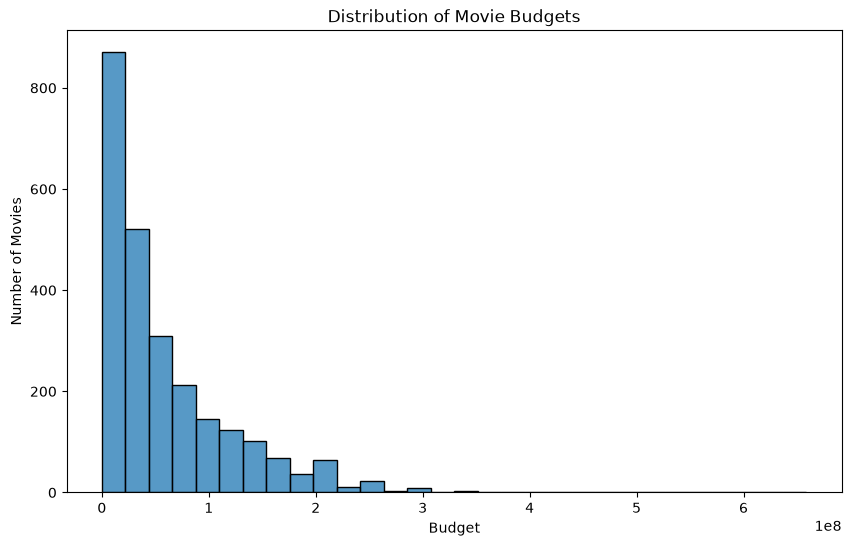

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=movies_df,
    x="budget",
    bins=30
)

plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.ylabel("Number of Movies")

plt.show()

#*Most movies have lower budgets, while a few movies have very high budgets.*

#Distribution of Movie Runtimes

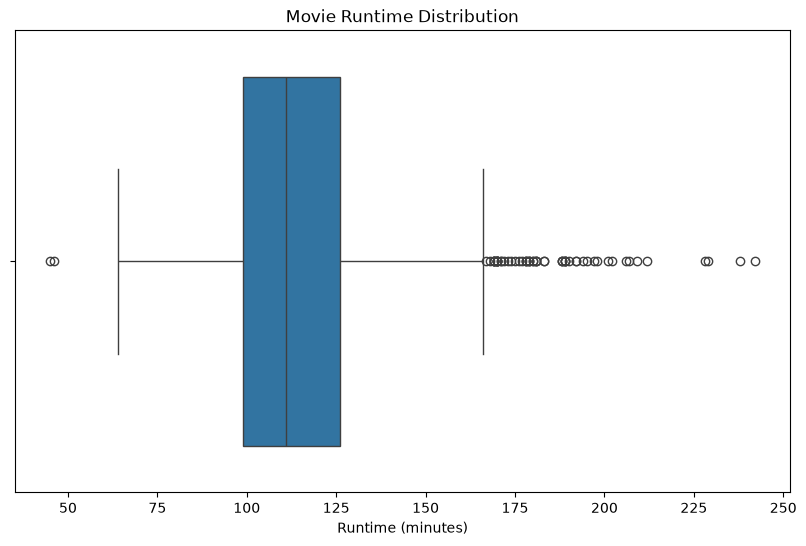

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movies_df,
    x="runtime"
)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (minutes)")

plt.show()

#*Most movies fall within a moderate runtime range, while a few unusually short or long movies stand out as outliers.*

### Distribution of Movie Ratings

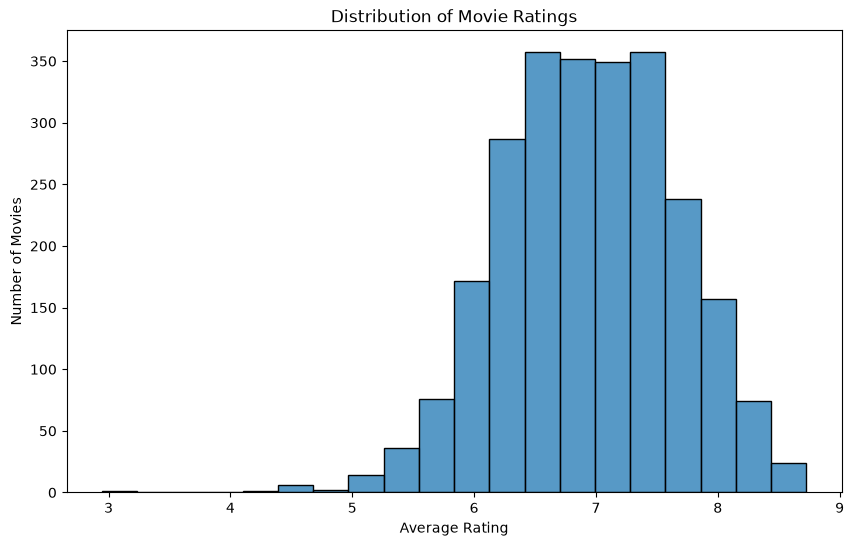

In [28]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=movies_df,
    x="vote_average",
    bins=20
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.show()

#*Most movies are concentrated around the middle rating range, with fewer movies receiving very high or very low ratings..*

#### Most Common Movie Languages

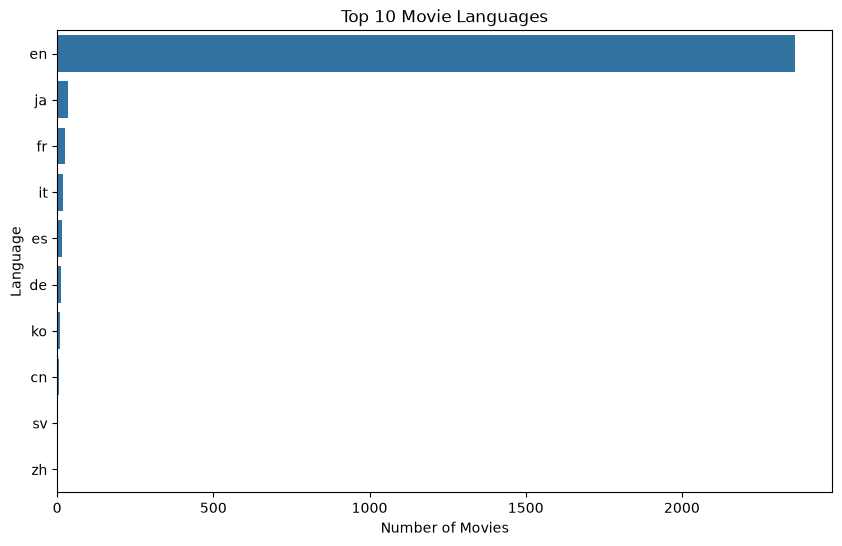

In [29]:
language_counts = (
    movies_df["original_language"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=language_counts.values,
    y=language_counts.index
)

plt.title("Top 10 Movie Languages")
plt.xlabel("Number of Movies")
plt.ylabel("Language")

plt.show()

#*English dominates the dataset, while the remaining movies are distributed across several other languages.*

### Budget vs Revenue

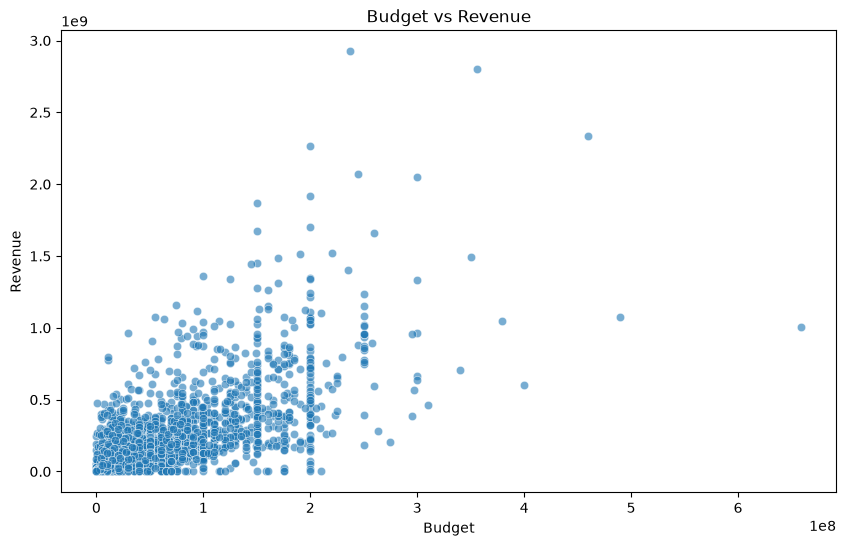

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movies_df,
    x="budget",
    y="revenue",
    alpha=0.6
)

plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

#*Movies with higher budgets generally tend to generate higher revenue*

### Popularity vs Vote Count

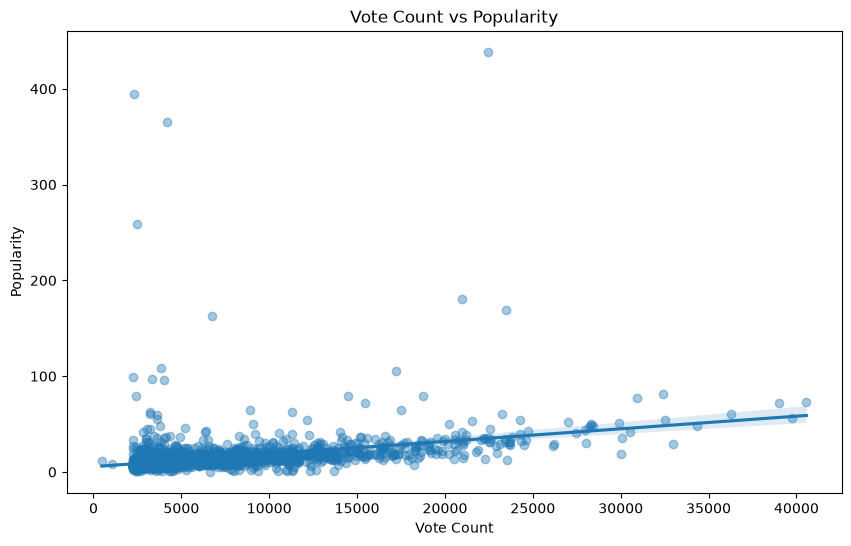

In [30]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies_df,
    x="vote_count",
    y="popularity",
    scatter_kws={"alpha": 0.4},
    line_kws={}
)

plt.title("Vote Count vs Popularity")
plt.xlabel("Vote Count")
plt.ylabel("Popularity")

plt.show()

#*Movies with higher vote counts generally show higher popularity, although there is considerable variation*

### Rating by movie status

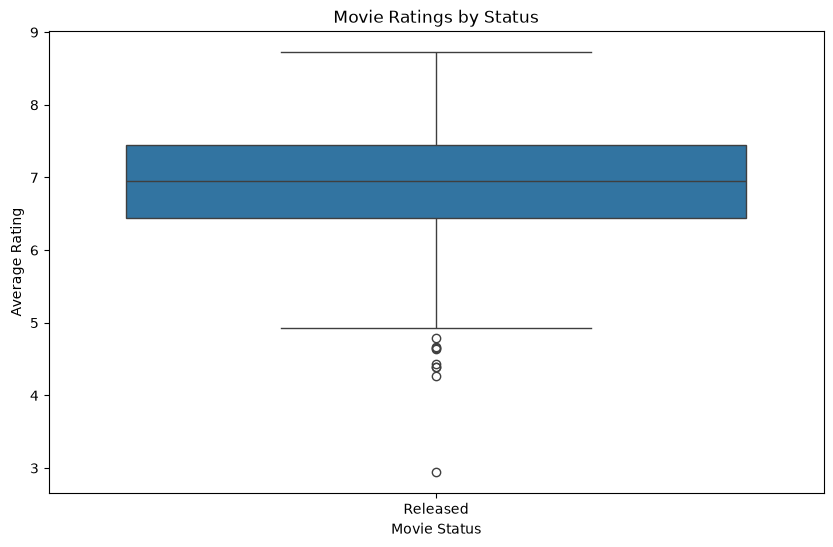

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movies_df,
    x="status",
    y="vote_average"
)

plt.title("Movie Ratings by Status")
plt.xlabel("Movie Status")
plt.ylabel("Average Rating")

plt.show()

#*Released movies show a wider range of ratings, while the other statuses have fewer movies and more limited rating patterns*

### Runtime vs Rating

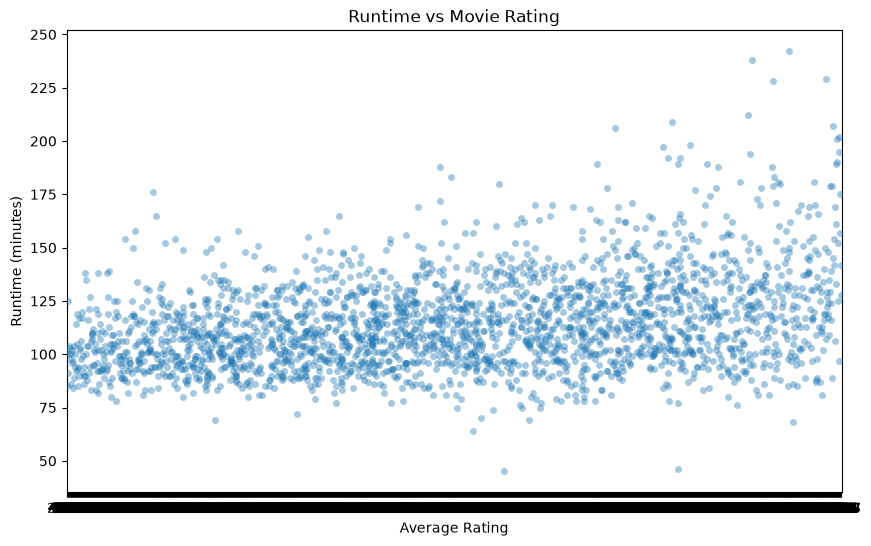

In [34]:
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=movies_df,
    x="vote_average",
    y="runtime",
    alpha=0.4
)

plt.title("Runtime vs Movie Rating")
plt.xlabel("Average Rating")
plt.ylabel("Runtime (minutes)")

plt.show()

#*Movie runtime varies across different rating levels, with no clear pattern between runtime and rating*

### Budget, Revenue & Rating

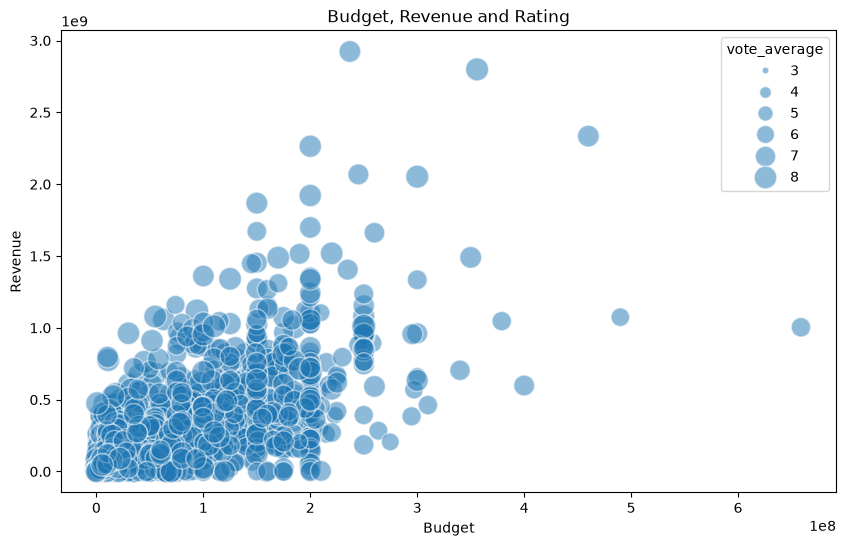

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movies_df,
    x="budget",
    y="revenue",
    size="vote_average",
    sizes=(20, 300),
    alpha=0.5
)

plt.title("Budget, Revenue and Rating")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

#*Higher-budget movies generally generate more revenue, while ratings vary across different budget levels*

### Genre, Rating & Popularity

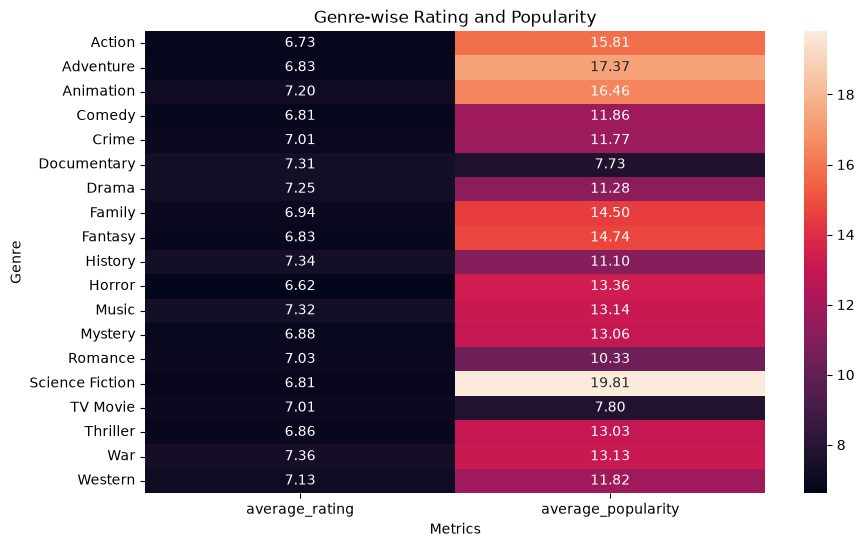

In [37]:
primary_genre = (
    movies_df
    .merge(movie_genres_df, on="movie_id")
    .merge(genres_df, on="genre_id")
)

genre_analysis = (
    primary_genre
    .groupby("genre_name")
    .agg(
        average_rating=("vote_average", "mean"),
        average_popularity=("popularity", "mean")
    )
    .round(2)
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    genre_analysis,
    annot=True,
    fmt=".2f"
)

plt.title("Genre-wise Rating and Popularity")
plt.xlabel("Metrics")
plt.ylabel("Genre")

plt.show()

#*Some genres stand out with higher average popularity, while rating differences between genres are relatively smaller.*